# Del dato al insight: Anscombe y Datasaurus


## 1. Tres indicadores que usamos todos los días

| Indicador | Qué resume | Fórmula (muestral) |
|---|---|---|
| **Media** | El "centro" de los valores | $\bar{x}=\frac{1}{n}\sum x_i$ |
| **Varianza muestral** | Cuánto se dispersan los valores alrededor de la media | $s^2=\frac{1}{n-1}\sum (x_i-\bar{x})^2$ |
| **Correlación de Pearson** | Qué tan bien una **recta** describe la relación entre X e Y (de −1 a 1) | $r=\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum (x_i-\bar{x})^2\sum (y_i-\bar{y})^2}}$ |

Además calcularemos la **recta de regresión lineal** $y = a + b\,x$ (pendiente $b$ e intercepto $a$) por mínimos cuadrados.

**Idea clave:** cada indicador comprime muchos puntos en un solo número. Al comprimir, se pierde información sobre la *forma* de los datos.

## 2. Librerías y configuración visual

In [1]:
import sys, platform, io, os
import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

# Paleta: fondo blanco, puntos morados, destacados en verde
MORADO = "#6A2C91"
VERDE  = "#1B9E5A"
GRIS   = "#4D4D4D"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.edgecolor": GRIS, "axes.labelcolor": GRIS, "xtick.color": GRIS, "ytick.color": GRIS,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 14, "axes.titlesize": 16, "axes.titleweight": "bold", "axes.labelsize": 14,
    "axes.grid": True, "grid.color": "#E6E6E6", "grid.linewidth": 0.8, "axes.axisbelow": True,
})

# Carpeta de salida para los PNG (se crea al ejecutar)
CARPETA_PNG = "graficos_png"
os.makedirs(CARPETA_PNG, exist_ok=True)

pd.set_option("display.float_format", lambda v: f"{v:.6f}")
pd.set_option("display.width", 200)

print("Versiones utilizadas")
print("  Python    :", platform.python_version())
print("  numpy     :", np.__version__)
print("  pandas    :", pd.__version__)
print("  scipy     :", scipy.__version__)
print("  matplotlib:", matplotlib.__version__)

Versiones utilizadas
  Python    : 3.10.20
  numpy     : 1.26.4
  pandas    : 2.3.3
  scipy     : 1.15.2
  matplotlib: 3.10.9


### Función reutilizable para calcular los indicadores
Se usa en **ambos** ejemplos, de modo que la comparación sea justa.

In [2]:
def indicadores(x, y):
    """Indicadores descriptivos de un conjunto de pares (x, y)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    reg = stats.linregress(x, y)          # mínimos cuadrados
    return {
        "n": int(len(x)),
        "media_x": x.mean(),
        "media_y": y.mean(),
        "varianza_x (ddof=1)": x.var(ddof=1),
        "varianza_y (ddof=1)": y.var(ddof=1),
        "correlación_pearson": np.corrcoef(x, y)[0, 1],
        "pendiente": reg.slope,
        "intercepto": reg.intercept,
        "R²": reg.rvalue ** 2,
    }

def tabla_indicadores(dic_datos):
    """dic_datos: {nombre: DataFrame con columnas x, y} -> tabla comparativa."""
    return pd.DataFrame({k: indicadores(v["x"], v["y"]) for k, v in dic_datos.items()}).T

def verificar(dic_datos, n_esperado):
    """Comprueba cantidad de observaciones y ausencia de valores faltantes."""
    for k, v in dic_datos.items():
        assert len(v) == n_esperado, f"{k}: se esperaban {n_esperado} observaciones y hay {len(v)}"
        assert v[["x", "y"]].notna().all().all(), f"{k}: hay valores faltantes"
        assert np.isfinite(v[["x", "y"]].to_numpy()).all(), f"{k}: hay valores no finitos"
    print(f"✔ {len(dic_datos)} conjuntos · {n_esperado} observaciones cada uno · sin valores faltantes")

---
# EJEMPLO 1 · El cuarteto de Anscombe

## 3. Datos de Anscombe
Cuatro conjuntos de 11 pares (X, Y) publicados por **Francis J. Anscombe (1973)**. Se incluyen **sin modificar y sin eliminar ningún punto**.

*Fuente:* Anscombe, F. J. (1973). *Graphs in Statistical Analysis*. The American Statistician, 27(1), 17–21. https://doi.org/10.1080/00031305.1973.10478966
Los conjuntos I, II y III comparten los mismos valores de X; el IV usa otros.

In [3]:
x_123 = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
x_4   = [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8]

anscombe = {
    "I":   pd.DataFrame({"x": x_123, "y": [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]}),
    "II":  pd.DataFrame({"x": x_123, "y": [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]}),
    "III": pd.DataFrame({"x": x_123, "y": [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]}),
    "IV":  pd.DataFrame({"x": x_4,   "y": [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]}),
}
verificar(anscombe, 11)
anscombe["I"].T

✔ 4 conjuntos · 11 observaciones cada uno · sin valores faltantes


,0,1,2,3,4,5,6,7,8,9,10
x,10.000000,8.000000,13.000000,9.000000,11.000000,14.000000,6.000000,4.000000,12.000000,7.000000,5.000000
y,8.040000,6.950000,7.580000,8.810000,8.330000,9.960000,7.240000,4.260000,10.840000,4.820000,5.680000


## 4. Tabla de indicadores de Anscombe
Se muestran 6 decimales para poder comprobar **qué coincide exactamente y qué solo aproximadamente**.

> por cada columna. ¿Hay alguna diferencia entre los cuatro conjuntos?

In [4]:
tabla_anscombe = tabla_indicadores(anscombe)
tabla_anscombe

,n,media_x,media_y,varianza_x (ddof=1),varianza_y (ddof=1),correlación_pearson,pendiente,intercepto,R²
I,11.000000,9.000000,7.500909,11.000000,4.127269,0.816421,0.500091,3.000091,0.666542
II,11.000000,9.000000,7.500909,11.000000,4.127629,0.816237,0.500000,3.000909,0.666242
III,11.000000,9.000000,7.500000,11.000000,4.122620,0.816287,0.499727,3.002455,0.666324
IV,11.000000,9.000000,7.500909,11.000000,4.123249,0.816521,0.499909,3.001727,0.666707


In [5]:
# Rango (máx − mín) de cada indicador entre los cuatro conjuntos: ¿cuánto difieren realmente?
rango = (tabla_anscombe.max() - tabla_anscombe.min()).rename("diferencia máx − mín")
pd.DataFrame({"mínimo": tabla_anscombe.min(), "máximo": tabla_anscombe.max(), "diferencia máx − mín": rango})

,mínimo,máximo,diferencia máx − mín
n,11.000000,11.000000,0.000000
media_x,9.000000,9.000000,0.000000
media_y,7.500000,7.500909,0.000909
varianza_x (ddof=1),11.000000,11.000000,0.000000
varianza_y (ddof=1),4.122620,4.127629,0.005009
correlación_pearson,0.816237,0.816521,0.000285
pendiente,0.499727,0.500091,0.000364
intercepto,3.000091,3.002455,0.002364
R²,0.666242,0.666707,0.000465


### Qué podemos afirmar (observación)
- **n = 11** en los cuatro conjuntos.
- La **media de X** es 9 **exactamente** en los cuatro; la **media de Y** coincide hasta ≈ 7,5 (valor redondeado habitual; difiere en el orden de 10⁻³ entre conjuntos).
- La **varianza de X** (11) coincide exactamente; la **varianza de Y** coincide solo **aproximadamente** (≈ 4,12 en todos, con diferencias de ≈ 0,005).
- La **correlación** es ≈ 0,816 en todos y la **recta** es ≈ y = 3,00 + 0,50·x: coinciden **aproximadamente**, con diferencias que solo aparecen a partir del 4.º decimal en la correlación y del 3.er en la recta.

*"Si solo hubiéramos recibido esta tabla, concluiríamos que los cuatro conjuntos son prácticamente el mismo dataset. Los indicadores están diciendo la verdad… pero ¿toda la verdad?"*

### Qué conclusión podemos sostener (todavía)
Que los **resúmenes numéricos son casi idénticos**. Aún **no** podemos decir nada sobre la forma de la relación.

## 5. Pregunta para el público (antes de revelar)

# ❓ Si los cuatro conjuntos tienen casi los mismos indicadores…
### ¿Cómo imaginan sus gráficos de dispersión?

- ¿Cuatro nubes parecidas con una recta ascendente?
- ¿Alguno distinto? ¿Cuál? ¿Por qué?



## 6. Revelación: los cuatro gráficos
Mismas escalas en los cuatro paneles, con la **recta de mínimos cuadrados** en verde. El punto destacado en verde marca la observación que más influye en los conjuntos III y IV.

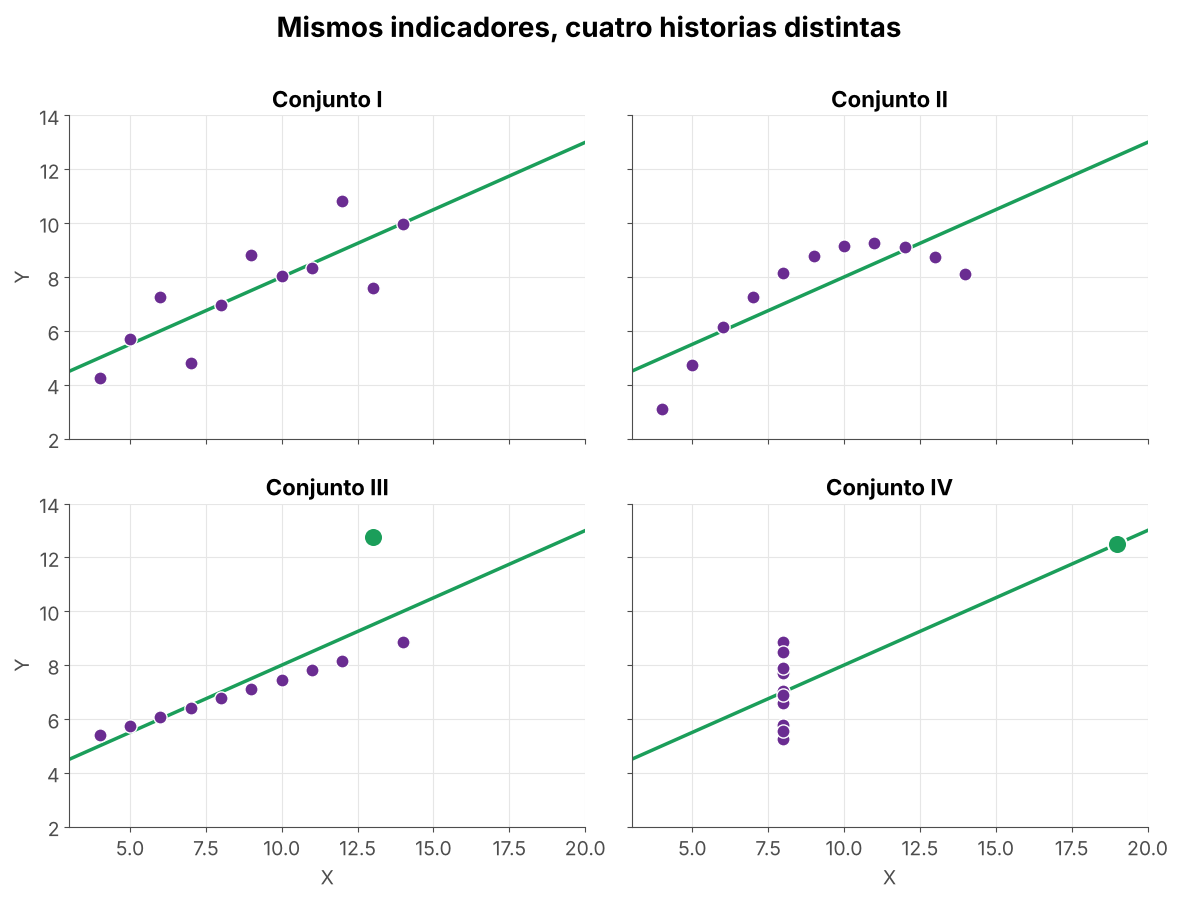

In [6]:
# Observación influyente a destacar (posición dentro del conjunto)
destacado = {"III": 2, "IV": 7}          # III: (13; 12,74)  ·  IV: (19; 12,50)

xs_lin = np.linspace(3, 20, 100)
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
for ax, (nombre, df) in zip(axes.ravel(), anscombe.items()):
    ind = indicadores(df["x"], df["y"])
    ax.plot(xs_lin, ind["intercepto"] + ind["pendiente"] * xs_lin, color=VERDE, lw=2.5, zorder=2)
    ax.scatter(df["x"], df["y"], s=90, color=MORADO, edgecolor="white", linewidth=1, zorder=3)
    if nombre in destacado:
        i = destacado[nombre]
        ax.scatter(df["x"].iloc[i], df["y"].iloc[i], s=190, color=VERDE, edgecolor="white", linewidth=1.5, zorder=4)
    ax.set_title(f"Conjunto {nombre}")
    ax.set_xlim(3, 20); ax.set_ylim(2, 14)
for ax in axes[1]: ax.set_xlabel("X")
for ax in axes[:, 0]: ax.set_ylabel("Y")
fig.suptitle("Mismos indicadores, cuatro historias distintas", fontsize=20, fontweight="bold", y=1.0)
fig.tight_layout()
fig.savefig(f"{CARPETA_PNG}/anscombe_cuadricula_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

### Qué observar (descripción de lo que se ve)
| Conjunto | Observación |
|---|---|
| **I** | Los puntos se reparten alrededor de la recta con dispersión moderada y sin estructura evidente adicional. Es una relación **aproximadamente lineal**. |
| **II** | Los puntos siguen una **curva** (sube y luego baja). La recta no describe adecuadamente esa forma, aunque su r sea casi igual. |
| **III** | Casi todos los puntos están muy cerca de una recta, salvo **un punto atípico** (verde) que **arrastra el ajuste** hacia arriba. |
| **IV** | Diez puntos comparten X = 8 y hay **uno solo con X diferente** (19, verde). Ese punto **determina buena parte del ajuste**: sin él no hay variación en X. |

### Qué explicar oralmente
- **I:** *"Este es el caso que imaginamos al ver la tabla: la recta resume bien."*
- **II:** *"Misma correlación, pero la relación es curva. Un modelo lineal aquí sería un error de forma, no de cálculo."*
- **III:** *"Un solo punto cambia la recta. Antes de decidir qué hacer con él hay que **investigar** por qué está ahí: ¿error de captura, caso real excepcional?"*
- **IV:** *"Toda la inclinación depende de una sola observación. Si ese dato falla, el resultado cambia por completo."*

### Qué conclusión podemos sostener
- **Observación:** los cuatro conjuntos tienen indicadores casi idénticos y formas muy distintas.
- **Interpretación (hay que justificarla con contexto):** en II la relación probablemente no es lineal; en III y IV hay observaciones con influencia desproporcionada. *Por qué* ocurre cada caso no lo dicen los datos: requiere conocer su origen.
- Visualizar **complementa** los indicadores: permite detectar curvas, agrupaciones y puntos atípicos que un número aislado no muestra.

---
## 7. Transición a Datasaurus

> *"Anscombe lo hizo a mano en 1973 con 11 puntos. ¿Se podrá llevar la idea al extremo, con más datos y formas que **no se parecen en nada** a una nube de puntos?"*

Alberto Cairo creó el *Datasaurus* original, y en 2017 Justin Matejka y George Fitzmaurice (Autodesk Research) desarrollaron un método para construir conjuntos con resúmenes casi idénticos y formas muy diferentes.

Usaremos **tres** conjuntos originales: **dino**, **circle** y **star**.

# EJEMPLO 2 · Datasaurus Dozen

## 8. Datos y tabla de indicadores
Los datos provienen del archivo original del *Datasaurus Dozen* distribuido en el repositorio del paquete **datasauRus** (R), y están **copiados tal cual** en la celda siguiente (sin redondear ni alterar). Así el notebook funciona sin internet.

- Origen del archivo: `jumpingrivers/datasauRus`, ruta `inst/extdata/DatasaurusDozen-Long.tsv` (GitHub, rama `main`).
- Publicación original: Matejka, J. & Fitzmaurice, G. (2017). *Same Stats, Different Graphs: Generating Datasets with Varied Appearance and Identical Statistics through Simulated Annealing*. CHI '17, 1290–1294. https://doi.org/10.1145/3025453.3025912
- Datasaurus original creado por Alberto Cairo.

In [9]:
# Datos copiados del archivo original DatasaurusDozen-Long.tsv (solo dino, circle, star; 142 puntos cada uno)
DATASAURUS_CSV = """dataset,x,y
dino,55.3846,97.1795
dino,51.5385,96.0256
dino,46.1538,94.4872
dino,42.8205,91.4103
dino,40.7692,88.3333
dino,38.7179,84.8718
dino,35.641,79.8718
dino,33.0769,77.5641
dino,28.9744,74.4872
dino,26.1538,71.4103
dino,23.0769,66.4103
dino,22.3077,61.7949
dino,22.3077,57.1795
dino,23.3333,52.9487
dino,25.8974,51.0256
dino,29.4872,51.0256
dino,32.8205,51.0256
dino,35.3846,51.4103
dino,40.2564,51.4103
dino,44.1026,52.9487
dino,46.6667,54.1026
dino,50.0,55.2564
dino,53.0769,55.641
dino,56.6667,56.0256
dino,59.2308,57.9487
dino,61.2821,62.1795
dino,61.5385,66.4103
dino,61.7949,69.1026
dino,57.4359,55.2564
dino,54.8718,49.8718
dino,52.5641,46.0256
dino,48.2051,38.3333
dino,49.4872,42.1795
dino,51.0256,44.1026
dino,45.3846,36.4103
dino,42.8205,32.5641
dino,38.7179,31.4103
dino,35.1282,30.2564
dino,32.5641,32.1795
dino,30.0,36.7949
dino,33.5897,41.4103
dino,36.6667,45.641
dino,38.2051,49.1026
dino,29.7436,36.0256
dino,29.7436,32.1795
dino,30.0,29.1026
dino,32.0513,26.7949
dino,35.8974,25.2564
dino,41.0256,25.2564
dino,44.1026,25.641
dino,47.1795,28.718
dino,49.4872,31.4103
dino,51.5385,34.8718
dino,53.5897,37.5641
dino,55.1282,40.641
dino,56.6667,42.1795
dino,59.2308,44.4872
dino,62.3077,46.0256
dino,64.8718,46.7949
dino,67.9487,47.9487
dino,70.5128,53.718
dino,71.5385,60.641
dino,71.5385,64.4872
dino,69.4872,69.4872
dino,46.9231,79.8718
dino,48.2051,84.1026
dino,50.0,85.2564
dino,53.0769,85.2564
dino,55.3846,86.0256
dino,56.6667,86.0256
dino,56.1538,82.9487
dino,53.8462,80.641
dino,51.2821,78.718
dino,50.0,78.718
dino,47.9487,77.5641
dino,29.7436,59.8718
dino,29.7436,62.1795
dino,31.2821,62.5641
dino,57.9487,99.4872
dino,61.7949,99.1026
dino,64.8718,97.5641
dino,68.4615,94.1026
dino,70.7692,91.0256
dino,72.0513,86.4103
dino,73.8462,83.3333
dino,75.1282,79.1026
dino,76.6667,75.2564
dino,77.6923,71.4103
dino,79.7436,66.7949
dino,81.7949,60.2564
dino,83.3333,55.2564
dino,85.1282,51.4103
dino,86.4103,47.5641
dino,87.9487,46.0256
dino,89.4872,42.5641
dino,93.3333,39.8718
dino,95.3846,36.7949
dino,98.2051,33.718
dino,56.6667,40.641
dino,59.2308,38.3333
dino,60.7692,33.718
dino,63.0769,29.1026
dino,64.1026,25.2564
dino,64.359,24.1026
dino,74.359,22.9487
dino,71.2821,22.9487
dino,67.9487,22.1795
dino,65.8974,20.2564
dino,63.0769,19.1026
dino,61.2821,19.1026
dino,58.7179,18.3333
dino,55.1282,18.3333
dino,52.3077,18.3333
dino,49.7436,17.5641
dino,47.4359,16.0256
dino,44.8718,13.718
dino,48.7179,14.8718
dino,51.2821,14.8718
dino,54.1026,14.8718
dino,56.1538,14.1026
dino,52.0513,12.5641
dino,48.7179,11.0256
dino,47.1795,9.8718
dino,46.1538,6.0256
dino,50.5128,9.4872
dino,53.8462,10.2564
dino,57.4359,10.2564
dino,60.0,10.641
dino,64.1026,10.641
dino,66.9231,10.641
dino,71.2821,10.641
dino,74.359,10.641
dino,78.2051,10.641
dino,67.9487,8.718
dino,68.4615,5.2564
dino,68.2051,2.9487
dino,37.6923,25.7692
dino,39.4872,25.3846
dino,91.2821,41.5385
dino,50.0,95.7692
dino,47.9487,95.0
dino,44.1026,92.6923
star,58.2136082599,91.881891513
star,58.1960536923,92.2149886482
star,58.7182307185,90.310532087
star,57.27837287,89.9076067166
star,58.082020494,92.0081450101
star,57.4894477748,88.0852855629
star,28.088741319,63.5107944263
star,28.0854682136,63.5901969481
star,28.087273053,63.1232828116
star,27.5780252176,62.8210386566
star,27.7799191139,63.518147517
star,28.5889998149,63.0240805653
star,28.7391414969,62.7208638859
star,27.0246032407,62.9018588649
star,28.8013366963,63.389040388
star,27.186463838,63.5587296478
star,29.2851466002,63.3836058254
star,39.4029453026,51.1508571967
star,28.8113284396,61.3578540576
star,34.3039579069,56.5421259093
star,29.6027609801,60.157346722
star,49.1161568603,63.6600006211
star,39.6175458263,62.9251879574
star,43.23308466,63.1652187223
star,64.8927879422,65.8141767574
star,62.4901493154,74.5842896072
star,68.9880844294,63.232147305
star,62.1056186306,75.9908707599
star,32.4618467439,62.8819029189
star,41.3272006535,49.0702512739
star,44.0071499323,46.4496737846
star,44.0740606888,34.5532038906
star,44.0013152386,33.9042073544
star,45.0063004454,38.2990195507
star,44.4438406096,36.0190833012
star,42.1787133986,26.492119482
star,44.0445656189,35.6622382764
star,41.6404540171,27.0930954213
star,41.9383300069,24.9915229793
star,44.0539275103,33.5563924949
star,39.2067193308,51.5337156971
star,28.7044492315,61.7775254006
star,31.7086628996,58.837754374
star,42.8117114739,30.0204484197
star,43.300614891,31.5264261979
star,40.3986329069,16.3470083822
star,40.4356915763,20.2326706762
star,40.9365466658,16.9130048364
star,39.6615736653,15.609355577
star,40.899259175,20.7985289466
star,41.9686168283,26.4970725985
star,40.3834058238,21.3912255247
star,56.5381264538,32.4442454697
star,52.9706912828,29.0401966941
star,54.6209525885,30.3445244537
star,65.0990443941,27.2415575588
star,63.0559909076,29.7090956748
star,70.9601362323,41.2595012867
star,69.8958192404,43.4537592655
star,70.5958928563,41.9647438672
star,69.6470214273,44.044445022
star,77.392982494,63.3714590552
star,64.4007871926,67.4487184472
star,63.8689598271,70.2137388333
star,56.5944213157,86.9270062202
star,56.5313372853,87.4998110713
star,59.6521583697,87.8094615921
star,56.6365087005,85.637495556
star,58.6722880025,90.077160307
star,58.2216127264,90.4110187715
star,57.9146644768,89.9538027677
star,55.3155090581,80.2518606944
star,54.5757285877,77.5362884724
star,54.4130936504,78.2290865878
star,55.0745059041,79.8175464166
star,29.4329605156,60.8017765444
star,29.4226860665,63.0684648229
star,29.0056141576,63.3907513334
star,58.4618385916,90.2653263904
star,57.997804739,92.1599086113
star,57.5494740761,90.7489065581
star,59.5299284566,88.3272741451
star,58.2493910631,92.1296814778
star,58.0245140126,91.6944211685
star,58.3821244904,90.5534760692
star,62.5667590405,77.7439347591
star,72.1758243064,63.1289294176
star,79.4727615693,63.4086861199
star,80.3577008812,63.2954375404
star,78.7572361375,53.3326200111
star,82.5402395934,56.5410522935
star,86.4358971909,59.7927618087
star,79.4886844186,53.6516742641
star,81.5304203188,56.0253645659
star,79.1867885665,53.2347918468
star,77.8990579454,51.8224583343
star,75.1307142075,23.3724419733
star,76.0580137544,16.3837496882
star,57.6146743876,33.8224476502
star,56.1713975295,32.1179887719
star,66.2878905956,26.1171097453
star,67.8817196169,24.2360184109
star,64.0280813016,27.6726855125
star,77.4966517463,14.9485235577
star,77.6346517616,14.461853927
star,77.8637264289,14.6106776491
star,77.3381581659,15.890054658
star,76.1804165329,15.9125737458
star,77.2526510945,15.1515170246
star,77.4133752817,15.2219279762
star,76.7318493982,16.2168461441
star,49.4711054118,25.0630193062
star,42.4765399431,18.3384735636
star,43.5951158622,19.9942009773
star,50.3399696652,26.4713966117
star,40.7489802561,16.1821416622
star,38.3865255803,14.5802151464
star,38.4040152085,14.4519484496
star,38.7642788913,14.3655904744
star,41.4701423265,17.2780334445
star,47.1554048146,22.3779325323
star,39.5825667453,17.6484528361
star,41.7402438167,17.8293243101
star,39.3118718889,15.6407169743
star,41.6798476925,17.7459190133
star,39.0874644519,15.1223039378
star,41.4815028637,18.0474374446
star,77.6060865492,15.1628725383
star,75.9826615205,16.3069223786
star,76.9457572424,15.858478334
star,77.5437200743,15.253949149
star,77.5847398447,15.8300393854
star,76.8223042562,15.5951653195
star,77.3485716647,15.7745292395
star,77.5731526867,14.7806458332
star,77.9726106776,14.9556987461
star,41.5289197586,24.9164251896
star,43.7225508034,19.0773278036
star,79.3260781751,52.9003912897
star,56.6639740815,87.9401250067
star,57.8217892319,90.6931665489
star,58.2431718991,92.1043278652
circle,55.9930301513,79.2772636977
circle,50.0322537946,79.013071199
circle,51.2884586593,82.4359398425
circle,51.1705368873,79.1652941091
circle,44.3779145287,78.1646280036
circle,45.0102700721,77.8808631153
circle,48.559816719,78.7883706035
circle,42.1422682922,76.8806345544
circle,41.0269715735,76.4095884613
circle,34.5753090115,72.7248411845
circle,31.1686007236,69.2454213193
circle,32.6442540714,70.7325550334
circle,26.6666456539,62.9809712052
circle,26.4592623274,62.6346733709
circle,25.5380076465,60.6302361093
circle,26.3207111933,62.3962811186
circle,26.1633874648,62.0268148985
circle,25.2137904611,60.2733986018
circle,26.8595295604,63.1418346727
circle,31.7606691716,69.7976553936
circle,39.7932905744,75.8079642168
circle,45.6174391854,78.1199702277
circle,53.7714606827,79.3029316435
circle,56.4514336733,79.2471070208
circle,66.0937201989,77.0178182606
circle,56.9258394194,79.2063186226
circle,58.9882538467,78.9172589554
circle,57.9022660533,79.0808678187
circle,64.8128669568,77.4869389235
circle,60.3497935166,78.7294458673
circle,48.890555756,16.8065435154
circle,47.549506348,17.0714045245
circle,30.8894308257,26.3290372348
circle,28.972835724,29.0504689185
circle,35.1613607523,22.7868496473
circle,45.8703691685,17.4893933655
circle,32.8314206076,24.7975381459
circle,39.4855747899,20.0330500489
circle,33.4461829314,24.1906434075
circle,21.8635812756,46.0525933457
circle,25.1658708449,35.7666139539
circle,22.9594789762,51.2877067934
circle,25.5860552415,60.8465833585
circle,26.3143100672,33.2971681038
circle,33.037301251,24.5644624921
circle,36.4688894772,21.8761144725
circle,26.5135531009,32.9187498178
circle,36.0270912125,22.1954385395
circle,42.6810404129,18.5425361977
circle,45.0410771273,17.7345177303
circle,47.3524164557,17.1347454264
circle,53.8461940322,16.3873180961
circle,55.1296393835,16.3532468711
circle,52.1881199617,16.4182174652
circle,58.6726630845,16.6633724322
circle,82.1443116037,33.1952218669
circle,75.6865711383,24.7415103908
circle,85.344964503,52.886419866
circle,83.8446535127,58.6160602305
circle,85.66476066,45.5427527692
circle,77.931004934,68.6900618808
circle,73.0318330209,73.12057473
circle,70.1028044999,75.6832068542
circle,57.1446946889,79.1941025922
circle,46.9624619942,78.6665589963
circle,50.5649338128,79.0772985529
circle,53.7196765696,79.306936167
circle,54.2002323226,79.3250023354
circle,47.875198343,78.6758534295
circle,51.4734585149,79.1598669963
circle,52.7512222162,79.2936599344
circle,48.5622230047,78.7823835275
circle,53.0812416908,79.2972507654
circle,56.475383374,79.1678400979
circle,49.570911405,79.0381238831
circle,37.6277032991,74.5575043418
circle,32.2637000863,70.3166389012
circle,32.542380336,70.7024172063
circle,52.8250171923,85.5781338795
circle,58.5282895407,78.9787042541
circle,56.265834263,79.2529394854
circle,57.0758924193,79.1939225382
circle,54.2564023808,79.3138648504
circle,62.6856712475,78.1747432719
circle,68.0856058616,76.1123175001
circle,65.1181219632,77.3991884543
circle,68.7456312971,75.7900554548
circle,63.0902251412,78.041409495
circle,77.2045893204,69.3121497658
circle,82.0339084758,62.6818697859
circle,81.5779459183,63.8949255005
circle,85.1801432805,53.7816766607
circle,84.2868249936,57.2561680896
circle,85.6224867126,45.0241658646
circle,85.6044990156,50.7623379055
circle,84.4247858276,38.761410164
circle,85.570985078,44.5600964397
circle,84.6267242006,39.4870775084
circle,73.3961549252,22.8162479426
circle,73.5074477338,22.8569887644
circle,63.3564881135,17.7240688424
circle,72.9590468722,22.5114998325
circle,64.0208416469,17.8835812521
circle,61.124463241,17.1163533592
circle,75.6742073297,24.7825009657
circle,69.5135831574,20.2793578927
circle,58.5721354669,16.642703808
circle,70.9819409865,21.1458881039
circle,65.2230303973,18.3971951223
circle,65.3150439093,18.3337482986
circle,64.0102406778,17.9244781912
circle,57.1409359294,16.5986105437
circle,56.3651532552,16.3265463742
circle,43.046183241,18.4025593948
circle,52.0817555582,16.4538745312
circle,42.8790365154,18.4894110252
circle,51.5669948027,16.4857136372
circle,58.8391251216,16.6376352154
circle,60.7557891374,17.0332315064
circle,54.7611561181,16.3661890954
circle,53.5699050003,16.3397125506
circle,48.9146182416,16.7986370826
circle,52.6461373069,16.3848363836
circle,49.8384929905,16.6763302777
circle,52.6840664009,16.4079627826
circle,65.8072190346,18.1407649473
circle,60.6739209233,17.0518023644
circle,63.394712866,17.7005351354
circle,64.8020094467,18.2168786335
circle,65.0259398087,18.2878245002
circle,65.7555515404,18.5162158303
circle,69.9677341245,20.5389887758
circle,68.8927840241,20.0324488429
circle,61.8265465579,17.2696554452
circle,60.7879700808,17.0462048583
circle,61.9156096372,17.2821912228
circle,45.0289975331,17.7244473049
circle,39.9213628084,19.7018495281
circle,84.7942778751,55.5686503735
circle,55.6629587449,83.3564796243
circle,50.4922475132,78.997532065
circle,51.4671011416,79.2018445773
"""

ds_largo = pd.read_csv(io.StringIO(DATASAURUS_CSV))
datasaurus = {k: ds_largo[ds_largo["dataset"] == k][["x", "y"]].reset_index(drop=True)
              for k in ["dino", "circle", "star"]}
verificar(datasaurus, 142)
datasaurus["dino"].head()

✔ 3 conjuntos · 142 observaciones cada uno · sin valores faltantes


,x,y
0,55.384600,97.179500
1,51.538500,96.025600
2,46.153800,94.487200
3,42.820500,91.410300
4,40.769200,88.333300


> 👀 **Qué observar:** compárense primero **entre ellos** (dino, circle, star). Después, si se desea, contrástense con Anscombe: **no tienen por qué coincidir** con los valores del cuarteto (otra media, otra varianza, otra correlación).

In [10]:
tabla_datasaurus = tabla_indicadores(datasaurus)
tabla_datasaurus

,n,media_x,media_y,varianza_x (ddof=1),varianza_y (ddof=1),correlación_pearson,pendiente,intercepto,R²
dino,142.000000,54.263273,47.832253,281.069988,725.515961,-0.064472,-0.103583,53.452978,0.004157
circle,142.000000,54.267320,47.837717,280.898024,725.226844,-0.068343,-0.109814,53.797045,0.004671
star,142.000000,54.267341,47.839545,281.197993,725.239695,-0.062961,-0.101113,53.326679,0.003964


In [11]:
rango_ds = (tabla_datasaurus.max() - tabla_datasaurus.min()).rename("diferencia máx − mín")
pd.DataFrame({"mínimo": tabla_datasaurus.min(), "máximo": tabla_datasaurus.max(), "diferencia máx − mín": rango_ds})

,mínimo,máximo,diferencia máx − mín
n,142.000000,142.000000,0.000000
media_x,54.263273,54.267341,0.004068
media_y,47.832253,47.839545,0.007292
varianza_x (ddof=1),280.898024,281.197993,0.299969
varianza_y (ddof=1),725.226844,725.515961,0.289117
correlación_pearson,-0.068343,-0.062961,0.005382
pendiente,-0.109814,-0.101113,0.008701
intercepto,53.326679,53.797045,0.470366
R²,0.003964,0.004671,0.000707


### Qué podemos afirmar (observación)
- n = 142 en los tres conjuntos.
- Las **medias** coinciden hasta aproximadamente el 2.º decimal (≈ 54,27 en X; ≈ 47,83 en Y).
- Las **varianzas** son muy similares entre sí (≈ 281 en X; ≈ 725 en Y), y la **correlación** es **débil y negativa** (≈ −0,06) en los tres.
- Estos valores **no** son los de Anscombe: lo que se compara es *dentro* de cada ejemplo.

*"Una correlación casi nula y negativa: un analista apurado diría 'no hay relación'. Y es cierto que **no hay una relación lineal**. ¿Pero no hay nada?"*

### Qué conclusión podemos sostener (todavía)
Los tres conjuntos son **casi indistinguibles según sus resúmenes**. Un r ≈ 0 solo indica ausencia de relación **lineal**, no ausencia de estructura.

## 9. Revelación: dinosaurio, círculo y estrella
Mismos límites de ejes (0–100) y **aspecto igual** (1:1) para no deformar las figuras.

# ❓ ¿Qué forma tendrá cada uno?

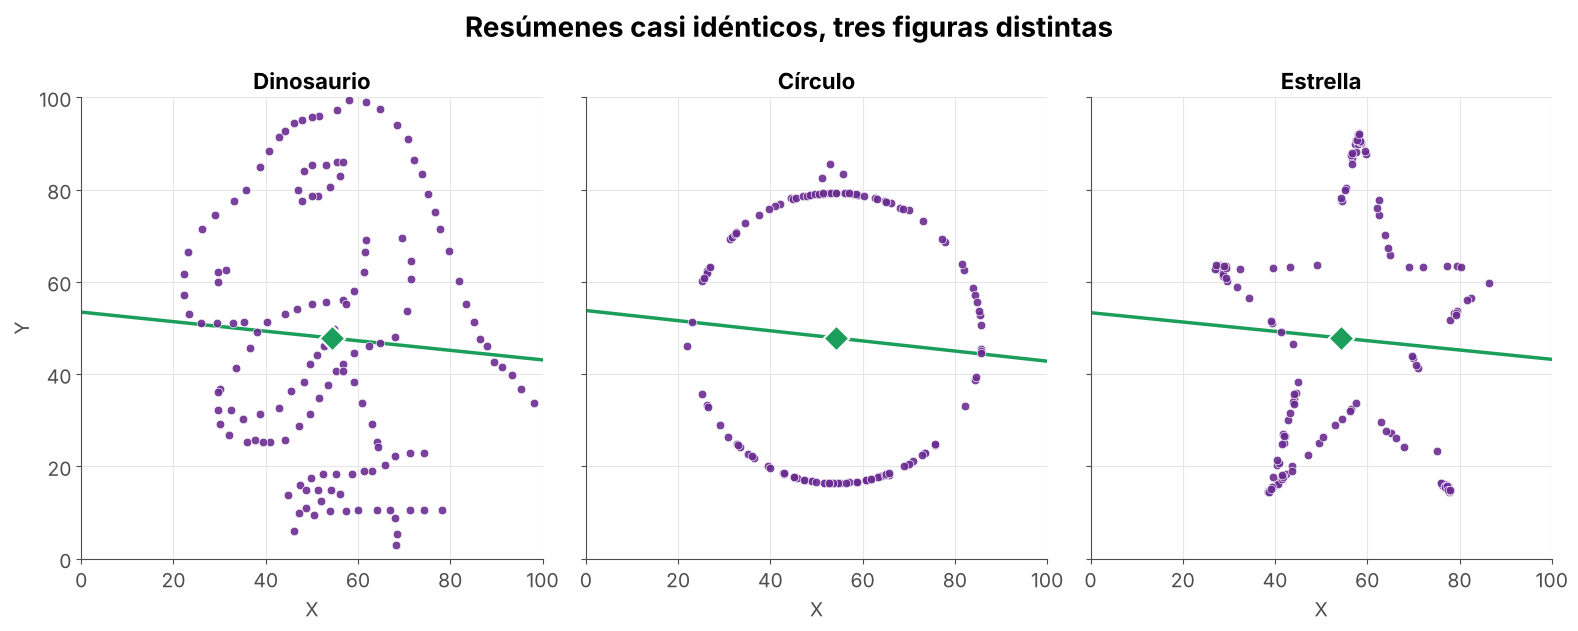

In [12]:
nombres_es = {"dino": "Dinosaurio", "circle": "Círculo", "star": "Estrella"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.8), sharex=True, sharey=True)
for ax, (k, df) in zip(axes, datasaurus.items()):
    ax.scatter(df["x"], df["y"], s=38, color=MORADO, alpha=0.9, edgecolor="white", linewidth=0.5, zorder=3)
    ind = indicadores(df["x"], df["y"])
    # elementos destacados en verde: punto de medias (centro) y recta ajustada
    xs = np.linspace(0, 100, 100)
    ax.plot(xs, ind["intercepto"] + ind["pendiente"] * xs, color=VERDE, lw=2.5, zorder=2)
    ax.scatter(ind["media_x"], ind["media_y"], s=170, marker="D", color=VERDE, edgecolor="white", linewidth=1.5, zorder=4)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect("equal", adjustable="box")
    ax.set_title(nombres_es[k]); ax.set_xlabel("X")
axes[0].set_ylabel("Y")
fig.suptitle("Resúmenes casi idénticos, tres figuras distintas", fontsize=20, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(f"{CARPETA_PNG}/datasaurus_dino_circle_star.png", dpi=300, bbox_inches="tight")
plt.show()

### Qué observar
Se reconocen tres figuras: un **dinosaurio**, un **círculo** y una **estrella**. En cada una, el **rombo verde** marca el punto de medias (muy parecido en los tres) y la **recta verde** es el ajuste lineal (casi plana, con la misma pendiente aproximada).

### Qué explicar oralmente
- *"Los números de la tabla eran prácticamente los mismos. La forma no tiene nada que ver."*
- *"Una recta casi horizontal no es 'ausencia de patrón': aquí hay patrones muy claros, solo que **no son lineales**."*
- *"Estos datos fueron generados con un algoritmo diseñado para conservar los resúmenes y cambiar la forma; en datos reales no suele pasar de forma tan extrema, pero el riesgo de resumir demasiado es el mismo."*

### Qué conclusión podemos sostener
- **Observación:** resúmenes casi iguales ⇒ formas completamente diferentes.
- **Interpretación:** r ≈ 0 no significa "no hay estructura"; significa "no hay estructura *lineal*".
- Visualizar permite detectar curvas, agrupaciones y puntos atípicos que los indicadores ocultan.

---
## 10. Conclusión 

> **“Los indicadores resumen los datos, pero no describen toda su estructura. Antes de construir una historia, necesitamos explorar y visualizar la evidencia.”**

| Paso | Qué hicimos hoy |
|---|---|
| **WHAT?** | Vimos que dos tablas de indicadores parecían describir lo mismo. |
| **SO WHAT?** | Al graficar, descubrimos curvas, puntos influyentes y figuras sin relación lineal: la decisión correcta depende de la forma, no solo del resumen. |
| **NOW WHAT?** | Antes de reportar un promedio, una correlación o una recta: **graficar la distribución y la relación**, buscar atípicos y preguntarse qué los explica. |



**Aplicación mañana:** en tu próximo dashboard, junto al KPI (media, tasa, correlación), añade un gráfico de la distribución o dispersión que lo sustenta.

**Límite honesto:** estos ejemplos muestran que los resúmenes *pueden* ocultar estructura; no que *siempre* lo hagan. Tampoco prueban causalidad.

## 11. Fuentes y notas de reproducibilidad

**Fuentes**
1. Anscombe, F. J. (1973). *Graphs in Statistical Analysis*. The American Statistician, 27(1), 17–21. https://doi.org/10.1080/00031305.1973.10478966
2. Matejka, J., & Fitzmaurice, G. (2017). *Same Stats, Different Graphs: Generating Datasets with Varied Appearance and Identical Statistics through Simulated Annealing*. Proceedings of CHI '17, 1290–1294. https://doi.org/10.1145/3025453.3025912
3. Datos del Datasaurus Dozen: repositorio del paquete **datasauRus** (Jumping Rivers), archivo `inst/extdata/DatasaurusDozen-Long.tsv`. https://github.com/jumpingrivers/datasauRus
4. Datasaurus original: Alberto Cairo.

**Notas de reproducibilidad**
- Todos los datos están **embebidos** en el notebook; no se descarga nada al ejecutarlo.
- Los datos de Anscombe se transcribieron de la publicación original y **no se modificaron**; los de Datasaurus se copiaron del archivo original **sin redondear**.
- Varianza muestral con `ddof=1`; correlación de Pearson con `numpy.corrcoef`; regresión por mínimos cuadrados con `scipy.stats.linregress`.
- Los gráficos se guardan en `graficos_png/` a 300 dpi con `bbox_inches="tight"`.
- Las versiones de las librerías se imprimen en la sección 2.
- Las salidas conservadas corresponden a una ejecución completa de principio a fin.

In [13]:
print("Archivos PNG generados:")
for f in sorted(os.listdir(CARPETA_PNG)):
    print(" -", f, f"({os.path.getsize(os.path.join(CARPETA_PNG, f))/1024:.0f} KB)")

Archivos PNG generados:
 - anscombe_cuadricula_2x2.png (301 KB)
 - datasaurus_dino_circle_star.png (416 KB)
